In [ ]:
!pip -q install -U yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.4 MB/s eta 0:00:00


In [19]:
import cv2
import os
import yt_dlp
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import files
from IPython.display import Video, display

In [ ]:
url = 'https://www.youtube.com/watch?v=xuP4g7IDgDM'

print('YouTube URL:', url)

YouTube URL: https://www.youtube.com/watch?v=xuP4g7IDgDM


In [21]:
url = 'https://www.youtube.com/watch?v=aqz-KE-bpKQ'

info_options = {
    'quiet': True,
    'no_warnings': True,
    'no_playlist': True
}

with yt_dlp.YoutubeDL(info_options) as ydl:
    video_info = ydl.extract_info(url, download=False)

print('Title:', video_info.get('title'))
print('Author / Uploader:', video_info.get('uploader'))
print('Channel:', video_info.get('channel'))
print('Duration (seconds):', video_info.get('duration'))
print('View count:', video_info.get('view_count'))
print('Webpage URL:', video_info.get('webpage_url'))
print('Rating: not reliably provided by current YouTube API')

Title: Big Buck Bunny 60fps 4K - Official Blender Foundation Short Film
Author / Uploader: Blender
Channel: Blender
Duration (seconds): 635
View count: 23402816
Webpage URL: https://www.youtube.com/watch?v=aqz-KE-bpKQ
Rating: not reliably provided by current YouTube API


In [ ]:
formats = video_info.get('formats')

for stream in formats:
    print(
        f"format_id={stream.get('format_id')}, "
        f"resolution={stream.get('resolution')}, "
        f"extension={stream.get('ext')}, "
        f"fps={stream.get('fps')}, "
        f"filesize={stream.get('filesize')}, "
        f"audio={stream.get('acodec') != 'none'}, "
        f"video={stream.get('vcodec') != 'none'}"
    )

format_id=sb3, resolution=48x27, extension=mhtml, fps=0.15748031496062992, filesize=None, audio=False, video=False
format_id=sb2, resolution=80x45, extension=mhtml, fps=0.2015748031496063, filesize=None, audio=False, video=False
format_id=sb1, resolution=160x90, extension=mhtml, fps=0.2015748031496063, filesize=None, audio=False, video=False
format_id=sb0, resolution=320x180, extension=mhtml, fps=0.2015748031496063, filesize=None, audio=False, video=False
format_id=233, resolution=audio only, extension=mp4, fps=None, filesize=None, audio=True, video=False
format_id=234, resolution=audio only, extension=mp4, fps=None, filesize=None, audio=True, video=False
format_id=139-drc, resolution=audio only, extension=m4a, fps=None, filesize=3871021, audio=True, video=False
format_id=249-drc, resolution=audio only, extension=webm, fps=None, filesize=3951579, audio=True, video=False
format_id=250-drc, resolution=audio only, extension=webm, fps=None, filesize=5215640, audio=True, video=False
format_

In [18]:
download_dir = Path('/content/youtube_downloads')
download_dir.mkdir(exist_ok=True)

video_options = {
    'format': 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/best',
    'outtmpl': str(download_dir / 'youtube_video.%(ext)s'),
    'noplaylist': True,
    'quiet': False,
    'merge_output_format': 'mp4'
}

with yt_dlp.YoutubeDL(video_options) as ydl:
    ydl.download([url])

video_files = list(download_dir.glob('youtube_video.*'))

if not video_files:
  raise FileNotFoundError('Video Could Not Be Downloaded')

download_video = str(video_files[0])

print('Downloaded Video:', download_video)

[youtube] Extracting URL: https://www.youtube.com/watch?v=aqz-KE-bpKQ
[youtube] aqz-KE-bpKQ: Downloading webpage


[youtube] aqz-KE-bpKQ: Downloading visionos player API JSON
[youtube] aqz-KE-bpKQ: Downloading m3u8 information
[info] aqz-KE-bpKQ: Downloading 1 format(s): 401+140
[download] /content/youtube_downloads/youtube_video.mp4 has already been downloaded
Downloaded Video: /content/youtube_downloads/youtube_video.mp4


In [ ]:
try:
  display(Video(download_video, embed=True, width=900))

except Exception as error:
  print('Video Preview Is Unavailable:', error)

Sample Frames: 6


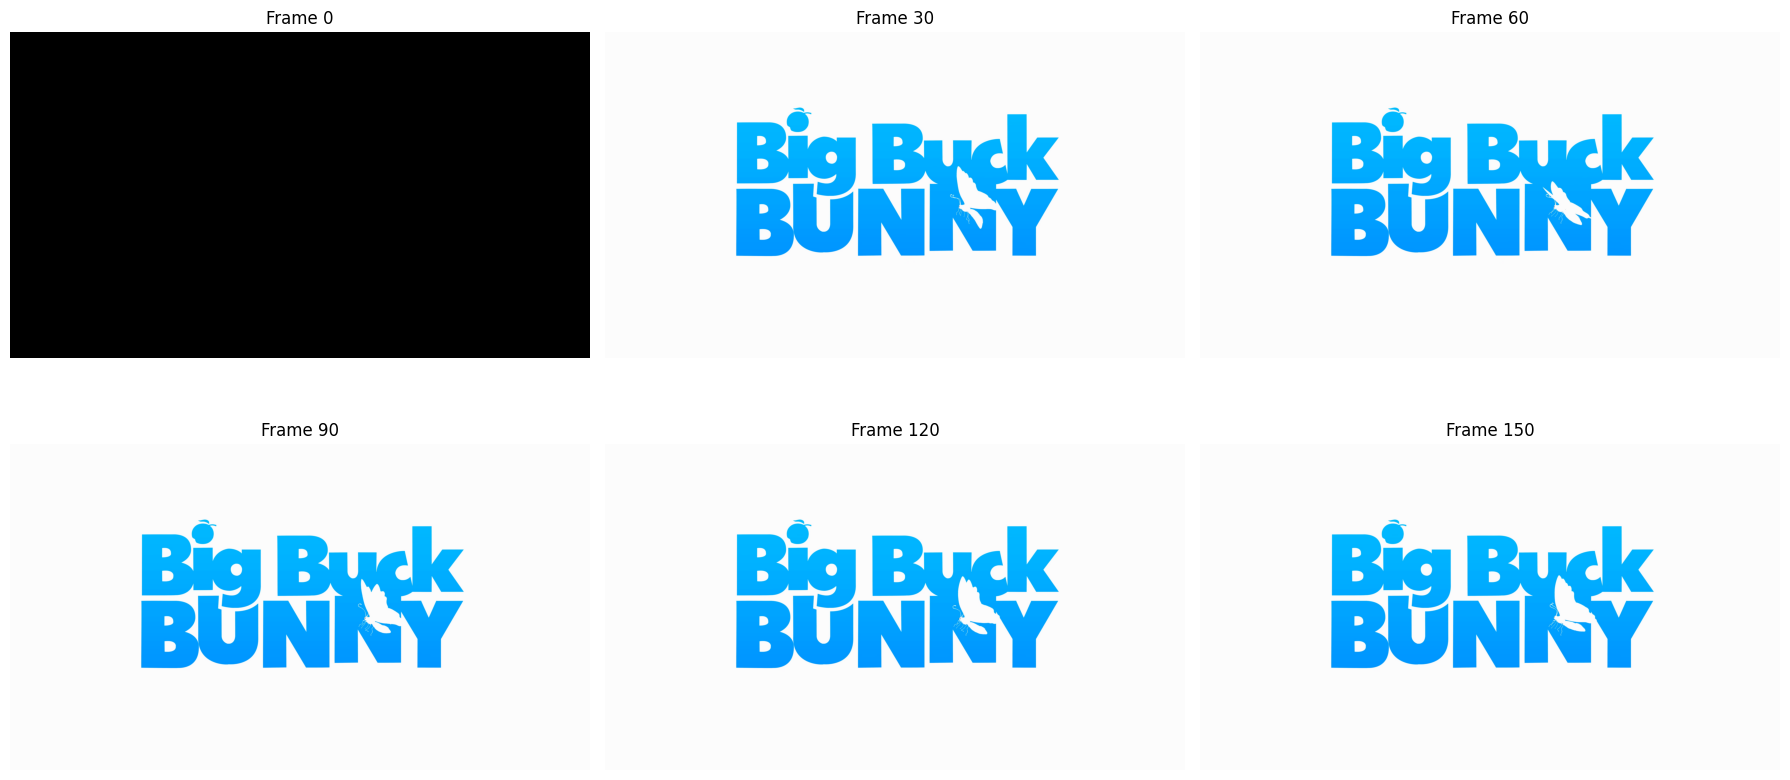

In [ ]:
capture = cv2.VideoCapture(download_video)

if not capture.isOpened():
  raise ValueError('Unable To Open Video File With OpenCV')

sample_frames = []
frame_indices = []
frame_number = 0

while len(sample_frames) < 6:
  ret, frame = capture.read()

  if not ret:
    break

  if frame_number % 30 == 0:
    sample_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    frame_indices.append(frame_number)
  frame_number += 1

capture.release()
print('Sample Frames:', len(sample_frames))

plt.figure(figsize=(18, 9))
for i, (frame_rgb, index) in enumerate(zip(sample_frames, frame_indices), start=1):
  plt.subplot(2, 3, i)
  plt.imshow(frame_rgb)
  plt.title(f'Frame {index}')
  plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
audio_options = {
    'format': 'bestaudio/best',
    'outtmpl': str(download_dir / 'youtube_audio.%(ext)s'),
    'noplaylist': True,
    'quiet': False
}

with yt_dlp.YoutubeDL(audio_options) as ydl:
    ydl.download([url])

audio_files = list(download_dir.glob('youtube_audio.*'))
print('Downloaded Audio Files:', [str(p) for p in audio_files])

[youtube] Extracting URL: https://www.youtube.com/watch?v=aqz-KE-bpKQ
[youtube] aqz-KE-bpKQ: Downloading webpage


[youtube] aqz-KE-bpKQ: Downloading visionos player API JSON
[youtube] aqz-KE-bpKQ: Downloading m3u8 information
[info] aqz-KE-bpKQ: Downloading 1 format(s): 251
[download] Destination: /content/youtube_downloads/youtube_audio.webm
[download] 100% of    9.73MiB in 00:00:00 at 29.20MiB/s  
Downloaded Audio Files: ['/content/youtube_downloads/youtube_audio.webm']


In [ ]:
for output_file in [Path(download_video), *audio_files]:
  if output_file.exists():
    print('Downloading:', output_file.name)
    files.download(str(output_file))